In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [6]:
df = pd.read_csv('/Users/dhruvsingh/Desktop/customer_shopping_analysis/customer_shopping_behavior.csv', encoding_errors = 'ignore')

In [7]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [8]:
df.shape

(3900, 18)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Shipping Type           3900 non-null   str    
 13  Discount Applied        3900 non-null   str    
 14  Promo Code Used         3900 non-null   str    
 15

In [11]:
df.ndim

2

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [17]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [18]:
df.describe(include = 'all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


Data cleaning

In [20]:
# Filling missing values in 'Review Rating' with the median rating for each category
df['Review Rating'] = df.groupby('Category')['Review Rating'].transform(lambda x: x.fillna(x.median()))

In [23]:
df.isnull().sum()

customer_id               0
age                       0
gender                    0
item_purchased            0
category                  0
purchase_amount_(usd)     0
location                  0
size                      0
color                     0
season                    0
review_rating             0
subscription_status       0
shipping_type             0
discount_applied          0
promo_code_used           0
previous_purchases        0
payment_method            0
frequency_of_purchases    0
dtype: int64

In [26]:
df.columns = df.columns.str.replace(' ', '_')
df.columns = df.columns.str.lower()
df = df.rename({'purchase_amount_(usd)': 'purchase_amount'}, axis = 1)

In [ ]:
df.columns


Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='str')

In [30]:
labels = ['Young adult', 'Adult', 'Middle-aged', 'Senior'] 
df['age_group'] = pd.qcut(df['age'],q=4, labels = labels)

In [32]:
df[['age', 'age_group']].head()

,age,age_group
0,55,Middle-aged
1,19,Young adult
2,50,Middle-aged
3,21,Young adult
4,45,Middle-aged


In [52]:
# df.drop('Age_group', axis =1,inplace = True)
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases', 'age_group',
       'purchase_frequency_days', 'discount_applied_with_promo'],
      dtype='str')

In [ ]:
# Mapping purchase frequency to numerical values (days)
frequency_mapping = {
'Fortnightly': 14,
'Weekly': 7,
'Monthly': 30,
'Quarterly': 90,
'Bi-Weekly': 14,
'Annually': 365,
'Every 3 Months': 90
}

df['purchase_frequency_days'] = df['frequency_of_purchases'].map(frequency_mapping)



In [43]:
df[['frequency_of_purchases', 'purchase_frequency_days']].head(10)

,frequency_of_purchases,purchase_frequency_days
0,Fortnightly,14
1,Fortnightly,14
2,Weekly,7
3,Weekly,7
4,Annually,365
5,Weekly,7
6,Quarterly,90
7,Weekly,7
8,Annually,365
9,Quarterly,90


In [45]:
df[['discount_applied', 'promo_code_used']].head(10)

,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
5,Yes,Yes
6,Yes,Yes
7,Yes,Yes
8,Yes,Yes
9,Yes,Yes


In [ ]:
df['discount_applied'] == df['discount_applied'].all()


0       True
1       True
2       True
3       True
4       True
        ... 
3895    True
3896    True
3897    True
3898    True
3899    True
Name: discount_applied, Length: 3900, dtype: bool

In [50]:
promo_code_mapping = {
    'Yes' : 1,
    'No' : 0
}
df['discount_applied_with_promo'] = df['discount_applied'] & df['promo_code_used'].map(promo_code_mapping)

In [51]:
df['discount_applied_with_promo'].head(10)

0    True
1    True
2    True
3    True
4    True
5    True
6    True
7    True
8    True
9    True
Name: discount_applied_with_promo, dtype: bool

In [ ]:
df.to_csv('customer_shopping_behavior_cleaned.csv')


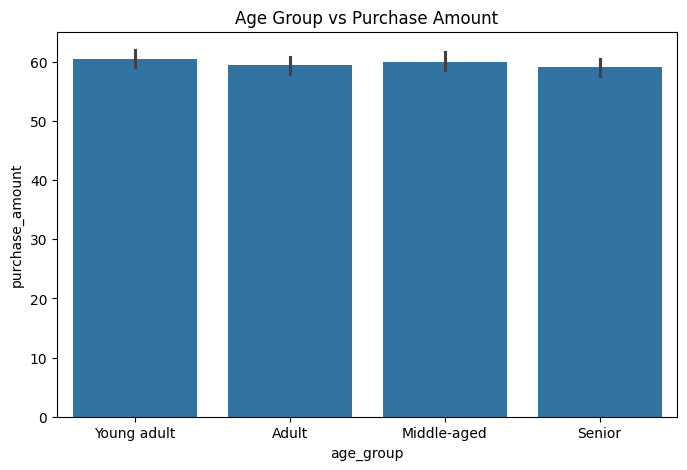

In [57]:
# age group vs purchase
plt.figure(figsize=(8,5))
sns.barplot(
    x="age_group",
    y="purchase_amount",
    data=df
)

plt.title("Age Group vs Purchase Amount")
plt.show()

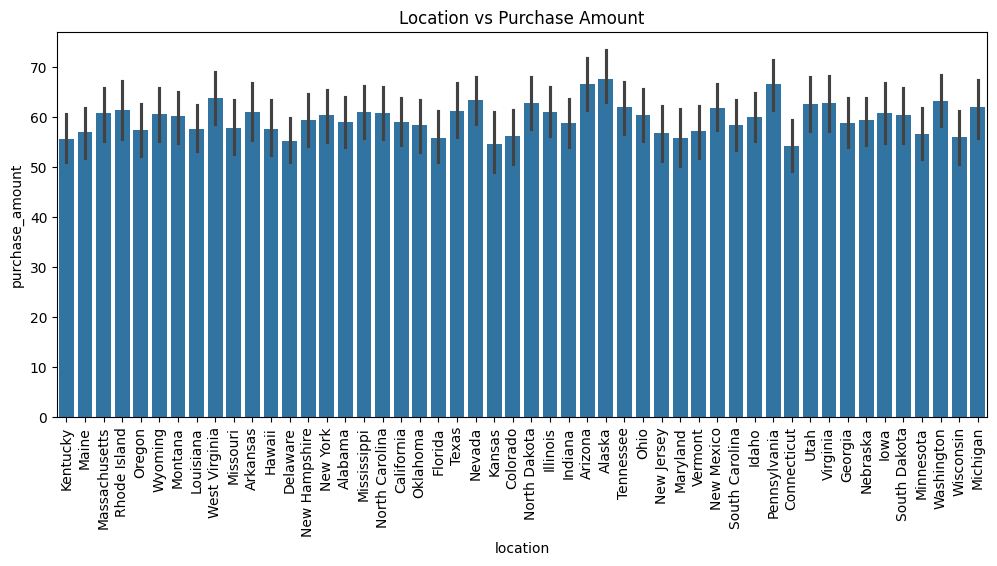

In [59]:
# location wise purchase
plt.figure(figsize=(12,5))
sns.barplot(
    x="location",
    y="purchase_amount",
    data=df
)

plt.xticks(rotation=90)
plt.title("Location vs Purchase Amount")
plt.show()


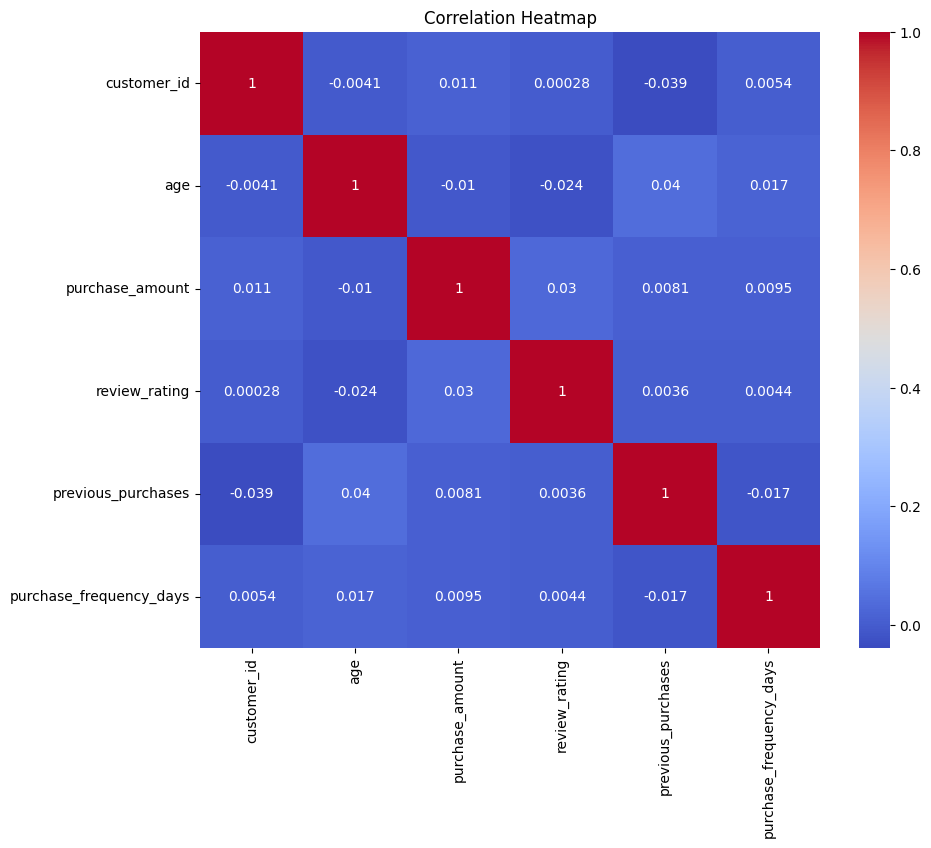

In [60]:
# correlation heatmap
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(10,8))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()


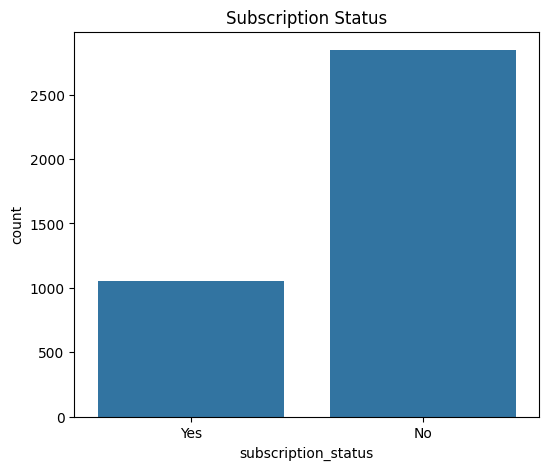

In [61]:
# subscription status
plt.figure(figsize=(6,5))
sns.countplot(x="subscription_status", data=df)
plt.title("Subscription Status")
plt.show()


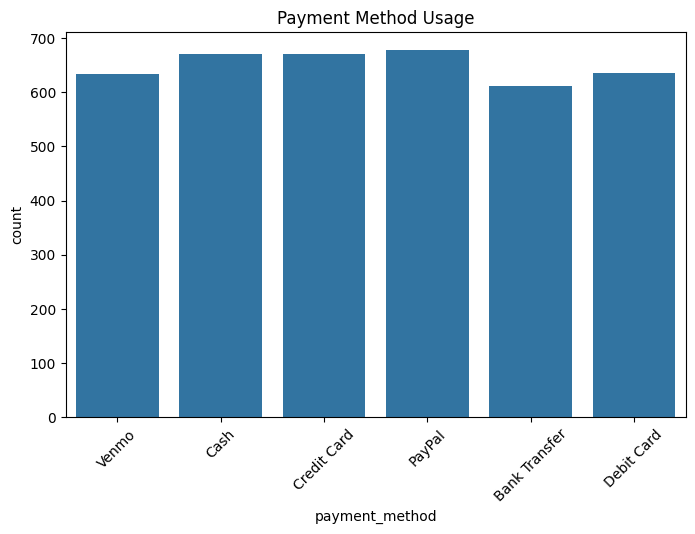

In [62]:
# payment method distribution
plt.figure(figsize=(8,5))
sns.countplot(x="payment_method", data=df)
plt.title("Payment Method Usage")
plt.xticks(rotation=45)
plt.show()


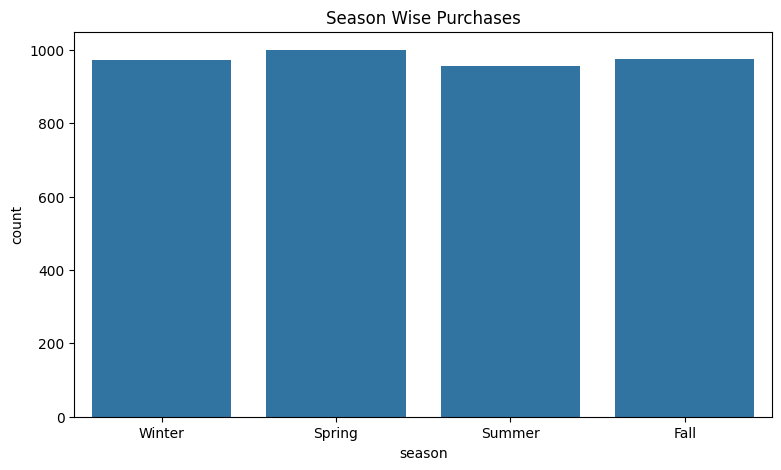

In [66]:
# season wise purchase
plt.figure(figsize=(9,5))
sns.countplot(x="season", data=df)
plt.title("Season Wise Purchases")
plt.show()

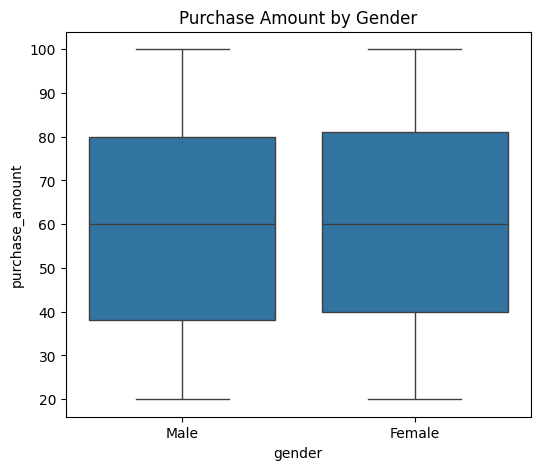

In [67]:
# purchase amount by gender
plt.figure(figsize=(6,5))
sns.boxplot(x="gender", y="purchase_amount", data=df)
plt.title("Purchase Amount by Gender")
plt.show()

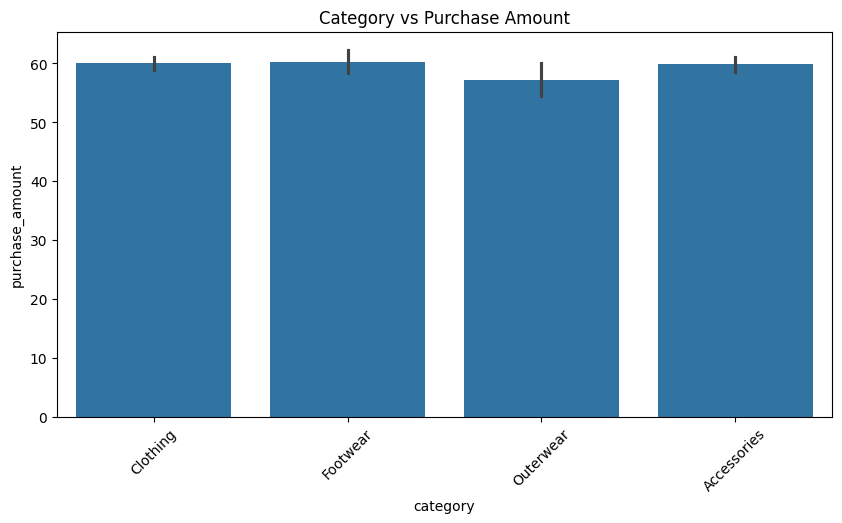

In [68]:
# category vs purchase amount
plt.figure(figsize=(10,5))
sns.barplot(x="category", y="purchase_amount", data=df)
plt.title("Category vs Purchase Amount")
plt.xticks(rotation=45)
plt.show()


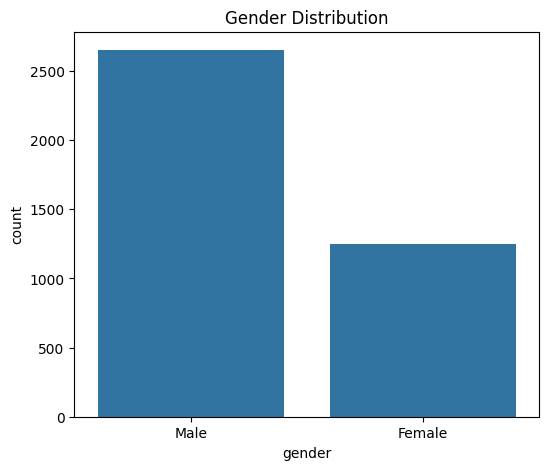

In [71]:
# gender count
plt.figure(figsize=(6,5))
sns.countplot(x="gender", data=df)
plt.title("Gender Distribution")
plt.show()

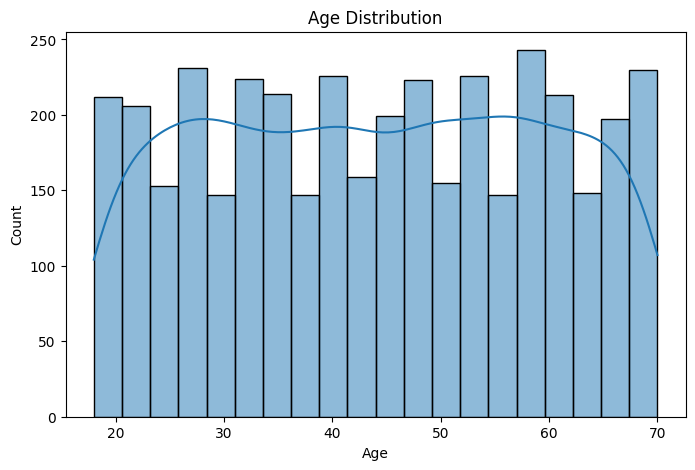

In [72]:
# age distribution
plt.figure(figsize=(8,5))
sns.histplot(df["age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


In [ ]:
# installing more dependencies for database connection and analysis
# pip install psycopg2-binary sqlalchemy

In [78]:
from sqlalchemy import create_engine, text

# Connect to the default 'postgres' database first
temp_engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/postgres")

# Create the new database
with temp_engine.connect() as conn:
    conn.execution_options(isolation_level="AUTOCOMMIT")
    conn.execute(text("CREATE DATABASE customer_behavior"))

print("Database created successfully!")

# Replace placeholders with your actual details
username = "dhruvsingh"
password = "10012007" 
host = "localhost"
port = "5432"
database = "customer_behavior"

# FIX: Changed ( ) to { }, fixed {password), and removed the space before port
engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

# Step 2: Load DataFrame into PostgreSQL
table_name = "customer"

# FIX: Removed space in .to_sql
df.to_sql(table_name, engine, if_exists="replace", index=False)

print(f"Data successfully loaded into table '{table_name}' in database '{database}'.")

Database created successfully!
Data successfully loaded into table 'customer' in database 'customer_behavior'.


In [82]:
df.to_excel('customer_shopping_behavior_cleaned_.xlsx', index=False)